### Tweede verkenning: onderzoeken van de nauwkeurigheid van Whisper modellen

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
BENCHMARK_DIR = Path("../../Data-local/processed/benchmark")

files = sorted(BENCHMARK_DIR.glob("*.json"))

files

[WindowsPath('../../Data-local/processed/benchmark/testaudio1_large-v3.json'),
 WindowsPath('../../Data-local/processed/benchmark/testaudio1_medium.json'),
 WindowsPath('../../Data-local/processed/benchmark/testaudio1_small.json'),
 WindowsPath('../../Data-local/processed/benchmark/testaudio2_large-v3.json'),
 WindowsPath('../../Data-local/processed/benchmark/testaudio2_medium.json'),
 WindowsPath('../../Data-local/processed/benchmark/testaudio2_small.json'),
 WindowsPath('../../Data-local/processed/benchmark/testaudio3_large-v3.json'),
 WindowsPath('../../Data-local/processed/benchmark/testaudio3_medium.json'),
 WindowsPath('../../Data-local/processed/benchmark/testaudio3_small.json'),
 WindowsPath('../../Data-local/processed/benchmark/testaudio4_large-v3.json'),
 WindowsPath('../../Data-local/processed/benchmark/testaudio4_medium.json'),
 WindowsPath('../../Data-local/processed/benchmark/testaudio4_small.json')]

Bovenstaand zijn de benchmark versies van de transcripties.
Er zijn vier audio fragmenten die hiervoor zijn gebruikt. Deze vier audio fragmenten bevatten situaties uit een klaslokaal. Audio 3 omvat een fragment van een Tiktok'er die voor de klas staat. Kinderen schreeuwen door elkaar heen, en er is een hoop ruis. 
De overige drie fragmenten zijn voorbeelden van youtuber en docent Peter Hoefnagels, alle drie fragmenten van verschillende situaties in een klaslokaal. De audio kwaliteit is hier duidelijk beter dan in het derde fragment. In dit onderzoek wordt gekeken naar hoeveel invloed audio kwaliteit en geluid heeft op de transcriptie van de modellen. Daarnaast wordt naar de nauwkeurigheid en de tijdsduur van de modellen gekeken. 

In [3]:
results = []

for file in files:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)

    results.append(data)

len(results)

12

In [4]:
results[0].keys()

dict_keys(['audio_file', 'language', 'duration', 'segments', 'model_size', 'transcription_time_seconds', 'transcription_config'])

In [5]:
summary = []

for data in results:
    summary.append({
        "audio_file": Path(data["audio_file"]).stem,
        "model": data["model_size"],
        "audio_duration_seconds": data["duration"],
        "transcription_time_seconds": data["transcription_time_seconds"],
        "segment_count": len(data["segments"])
    })

df_summary = pd.DataFrame(summary)

df_summary

,audio_file,model,audio_duration_seconds,transcription_time_seconds,segment_count
0,testaudio1,large-v3,299.932187,653.84,97
1,testaudio1,medium,299.932187,181.41,75
2,testaudio1,small,299.932187,76.85,89
3,testaudio2,large-v3,464.166875,1296.43,292
4,testaudio2,medium,464.166875,496.80,273
5,testaudio2,small,464.166875,272.01,268
6,testaudio3,large-v3,68.911000,264.97,24
7,testaudio3,medium,68.911000,43.54,11
8,testaudio3,small,68.911000,39.53,23
9,testaudio4,large-v3,315.652062,878.59,253


In [6]:
df_summary["audio_duration_minutes"] = (
    df_summary["audio_duration_seconds"] / 60
)

df_summary["transcription_time_minutes"] = (
    df_summary["transcription_time_seconds"] / 60
)

df_summary["realtime_factor"] = (
    df_summary["transcription_time_seconds"]
    / df_summary["audio_duration_seconds"]
)

df_summary.round(2)

,audio_file,model,audio_duration_seconds,transcription_time_seconds,segment_count,audio_duration_minutes,transcription_time_minutes,realtime_factor
0,testaudio1,large-v3,299.93,653.84,97,5.00,10.90,2.18
1,testaudio1,medium,299.93,181.41,75,5.00,3.02,0.60
2,testaudio1,small,299.93,76.85,89,5.00,1.28,0.26
3,testaudio2,large-v3,464.17,1296.43,292,7.74,21.61,2.79
4,testaudio2,medium,464.17,496.80,273,7.74,8.28,1.07
5,testaudio2,small,464.17,272.01,268,7.74,4.53,0.59
6,testaudio3,large-v3,68.91,264.97,24,1.15,4.42,3.85
7,testaudio3,medium,68.91,43.54,11,1.15,0.73,0.63
8,testaudio3,small,68.91,39.53,23,1.15,0.66,0.57
9,testaudio4,large-v3,315.65,878.59,253,5.26,14.64,2.78


In [7]:
comparison = df_summary[
    [
        "audio_file",
        "model",
        "audio_duration_minutes",
        "transcription_time_minutes",
        "realtime_factor",
        "segment_count"
    ]
].sort_values(["audio_file", "model"])

comparison.round(2)

,audio_file,model,audio_duration_minutes,transcription_time_minutes,realtime_factor,segment_count
0,testaudio1,large-v3,5.00,10.90,2.18,97
1,testaudio1,medium,5.00,3.02,0.60,75
2,testaudio1,small,5.00,1.28,0.26,89
3,testaudio2,large-v3,7.74,21.61,2.79,292
4,testaudio2,medium,7.74,8.28,1.07,273
5,testaudio2,small,7.74,4.53,0.59,268
6,testaudio3,large-v3,1.15,4.42,3.85,24
7,testaudio3,medium,1.15,0.73,0.63,11
8,testaudio3,small,1.15,0.66,0.57,23
9,testaudio4,large-v3,5.26,14.64,2.78,253


Uit de korte onderzoeken van hierboven blijkt dat het Large model de meeste segments produceert (segment_count). Dit betekent dat hij vaker dialogen in kleine uitingen opdeelt. De drie verschillende audio's hebben allen verschillende tijdsduren.
Aan de realtime_factor kun je duidelijk zien dat het Large model ook het meeste tijd inneemt. 
Bijvoorbeeld: Testaudio1 duurt 299.93 seconden totaal. Het transcriberen ervan duurde 653.84 seconden. Dit betekent in het kort dat een fragment van vijf minuten in totaal tien minuten duurt om te transciberen. In de realtime_factor kun je zien dat het large model 2.18 seconden doet over 1 seconde van een audio fragment. 

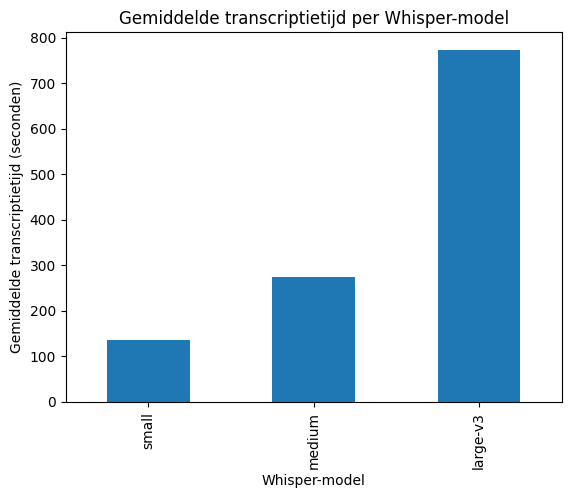

In [8]:
model_times = (
    df_summary
    .groupby("model")["transcription_time_seconds"]
    .mean()
    .sort_values()
)

model_times.plot(kind="bar")

plt.ylabel("Gemiddelde transcriptietijd (seconden)")
plt.xlabel("Whisper-model")
plt.title("Gemiddelde transcriptietijd per Whisper-model")
plt.show()

Kortom, het Large-v3 whisper model neemt gemiddeld het meeste tijd in per transcriptie. De vraag is nu of dit het waard is voor het daadwerkelijke eindproduct, aangezien ditzelfde model bijna 22 minuten nam voor een transcriptie van een geluidsfragment van zeven minuten. Workshops zullen meer tijd innemen, waardoor het model waarschijnlijk vele malen langer zal gaan werken. Dit wordt onderzocht in een toekomstig onderzoek. 

#### Onderzoek van de transcriptie tekst

In [9]:
def get_result(audio_name, model):
    for data in results:
        if (
            Path(data["audio_file"]).stem == audio_name
            and data["model_size"] == model
        ):
            return data

    return None

In [10]:
large = get_result("testaudio2", "large-v3")

large["segments"][:5]

[{'start': 0.0,
  'end': 1.4,
  'speaker': None,
  'text': 'Dan gaat alles op en neer bij jou.',
  'avg_logprob': -0.24065238416481477,
  'no_speech_prob': 0.19203417003154755,
  'compression_ratio': 1.7119741100323624,
  'quality_flags': []},
 {'start': 1.6,
  'end': 3.64,
  'speaker': None,
  'text': "Ja, maar dat komt gewoon omdat ik een druk-ADAD'er ben.",
  'avg_logprob': -0.24065238416481477,
  'no_speech_prob': 0.19203417003154755,
  'compression_ratio': 1.7119741100323624,
  'quality_flags': []},
 {'start': 3.78,
  'end': 5.74,
  'speaker': None,
  'text': "Ja, je moeder ook, dat je een ADAD'er bent.",
  'avg_logprob': -0.24065238416481477,
  'no_speech_prob': 0.19203417003154755,
  'compression_ratio': 1.7119741100323624,
  'quality_flags': []},
 {'start': 5.98,
  'end': 6.3,
  'speaker': None,
  'text': 'Wat?',
  'avg_logprob': -0.24065238416481477,
  'no_speech_prob': 0.19203417003154755,
  'compression_ratio': 1.7119741100323624,
  'quality_flags': []},
 {'start': 6.56,
  '

In [11]:
def get_segments_between(data, start, end):
    return [
        segment
        for segment in data["segments"]
        if segment["start"] < end and segment["end"] > start
    ]

In [12]:
segments = get_segments_between(
    large,
    start=30,
    end=50
)

for segment in segments:
    print(
        f"[{segment['start']:.2f} - {segment['end']:.2f}] "
        f"{segment['text']}"
    )

[31.02 - 31.88] Opdracht 4.
[32.06 - 33.02] Wie heb ik nog niet gehoord?
[33.68 - 34.84] Ja, iemand met paars haar.
[34.86 - 35.50] Wat is dat met mijn haar?
[35.84 - 36.36] Nee, dat vind ik mooi.
[36.36 - 37.98] Als ik jong was, had ik dat ook gedaan.
[38.50 - 40.18] Maar ik ben eigenlijk wel jong, vind je niet?
[40.26 - 40.50] Nee.
[41.68 - 42.66] Zou ik paars...
[42.66 - 43.48] Oude zak ben je.
[43.84 - 44.02] Een?
[44.60 - 45.20] Oude zak.
[46.02 - 49.80] Ja, even een beetje op je woorden letten, Tos.


Hieronder worden korte vergelijkingen gedaan tussen drie modellen met de verschillende fragmenten.

In [13]:
def compare_models(audio_name, start, end, models=("small", "medium", "large-v3")):
    for model in models:
        data = get_result(audio_name, model)

        print("=" * 80)
        print(model.upper())
        print("=" * 80)

        if data is None:
            print("Geen resultaat gevonden.")
            continue

        segments = get_segments_between(data, start, end)

        for segment in segments:
            print(
                f"[{segment['start']:.2f} - {segment['end']:.2f}] "
                f"{segment['text']}"
            )

        print()

In [14]:
compare_models(
    audio_name="testaudio2",
    start=55,
    end=75
)

SMALL
[54.34 - 55.06] Zegt u het maar.
[55.06 - 57.06] Ja, kijk maar even in je schrift op de vier.
[57.06 - 58.14] Ruud heeft een brommer.
[58.14 - 59.78] De text gaat toch niet over brommer, wel wel.
[59.78 - 61.38] Nee, maar het gaat ook niet over brommer.
[61.38 - 62.38] Maar Ruud heeft een probleem.
[62.38 - 63.10] Dat is de vraag.
[63.10 - 64.78] Wat soort probleem heeft-ie?
[64.78 - 67.10] Ja, met z'n vrouw.
[67.10 - 67.82] Nee, klopt niet.
[67.82 - 68.58] Ik bedoel met z'n hond.
[68.58 - 70.06] Ja, je bent gewoon verzinnen, of niet?
[70.06 - 70.74] Nee, je wel.
[70.74 - 71.74] Wat staat-ie? Echt waar?
[71.74 - 72.90] Ja, het staat in jouw schrift.
[72.90 - 74.62] Maar misschien staat het niet eens in schrift.
[74.62 - 75.74] Misschien zie je het gewoon in te verzinnen.

MEDIUM
[54.98 - 55.98] Ja, kijk maar even in je schrift.
[55.98 - 56.98] Optracht vier.
[56.98 - 57.98] Ruud heeft een brommer.
[57.98 - 59.78] De tekst gaat toch niet over brommer, of wel?
[59.78 - 61.38] Nee, 

In [15]:
compare_models(
    audio_name="testaudio1",
    start=40,
    end=80
)

SMALL
[37.85 - 42.61] Ik heb deze opdracht heel breed gehouden zodat jullie vrij kunnen associeren
[42.77 - 45.77] en met dat thema lekker aan de slag kunnen gaan.
[45.93 - 51.05] En met lekker zijn er drie presentaties, geloof ik.
[51.21 - 55.13] Een duo. En ik heb wel een beetje idee wie het duo is hier.
[55.29 - 57.25] Volgens mij is het Eén Maxime.
[57.41 - 59.09] En wie is dan naam?
[59.25 - 62.05] Dat is Tessa, je hebt ook volgens, wat je hebt?
[62.21 - 63.61] Je hebt ook iets.
[63.73 - 66.17] Dan nu naam Maxime.
[66.33 - 68.01] Je hebt ook een presentatie voorbereid.
[68.17 - 69.61] Wie ben ik?
[69.77 - 71.93] Heb je daar ooit een hele plastic zak bij je?
[73.61 - 74.61] Ga je al beginnen?
[74.77 - 75.77] Oké.
[75.93 - 79.17] Ik ga vandaag een taart maken.
[79.33 - 83.09] Daarin ga ik beschrijven wie ik ben.

MEDIUM
[37.45 - 41.61] je bent, maar ik heb deze opdracht vooral heel breed gehouden zodat
[41.77 - 46.05] jullie vrij kunnen associëren en met dat thema lekker aan de slag

In [16]:
compare_models(
    audio_name="testaudio4",
    start=20,
    end=65
)

SMALL
[18.34 - 20.68] Houd je mond!
[20.68 - 22.04] Wat? Wie zei dat nou?
[22.60 - 23.60] Ja.
[23.60 - 24.60] Wat?
[24.60 - 25.36] Jij.
[25.36 - 26.76] Ik zei houd op tegen Emma.
[27.76 - 28.96] Nou, hou er maar mee op.
[28.96 - 31.04] Ja, net als ze zitten in mijn schriftekrassen.
[31.04 - 32.04] Ja, dat is niet...
[32.04 - 33.04] Ik ben gewoon aan het werk.
[33.04 - 34.24] Je ziet het toch hier?
[34.24 - 36.04] Ja, dat is wel vervuld.
[36.68 - 38.28] Nou, dat is niet bedoeling, Emma.
[38.28 - 40.28] Jullie zijn toch twee goede vriendinnen?
[40.28 - 40.88] Ja, ik zie het.
[40.88 - 42.08] Nou, precies.
[42.72 - 44.72] Ja, kijk eens, ik krijg hier een mooie lach van Emma.
[44.72 - 46.72] Ja, maar kunt u er niet wat van zeggen?
[46.72 - 48.72] Nou, ik zeg het nou toch, Emma.
[48.72 - 49.72] Niet doen.
[49.72 - 50.72] Niet lopen krassen.
[50.72 - 52.72] Ook niet voor de grap, of zo.
[52.72 - 53.72] Ja, ineens goed.
[53.72 - 54.72] Ik stop al met...
[54.72 - 55.72] Oké, oké.
[55.72 - 56.72

### Interne kwaliteitsindicatoren van spraakherkenning

Na het vergelijken van de drie modellen op het tekstueel vlak en de tijdsduur, is het ook interessant om te kijken naar de kwaliteitsindicatoren. Hierbij kijken we naar de ASR statistieken. ASR staat voor Automatic Speech Recognition: automatische spraakherkenning. (Het ASR systeem is Whisper)

Per segment wordt er gekeken naar: 
- Begin- en eindtijd
- Tekst
- Welk model het was
- avg_logprob: hoe zeker is Whisper over zijn eigen voorspelling (minder negatief is gunstiger)
- no_speech_prob: inschatting dat er geen spraak zat in dat stuk audio. Een hoge waarde kan interessant zijn als Whisper toch tekst er neerzet
- compression_ratio: wordt gebruikt om rare repetitieve/hallicunerende output te signaleren. 

In [17]:
segment_rows = []

for data in results:
    audio_name = Path(data["audio_file"]).stem
    model = data["model_size"]

    for segment in data["segments"]:
        segment_rows.append({
            "audio_file": audio_name,
            "model": model,
            "start": segment["start"],
            "end": segment["end"],
            "duration": segment["end"] - segment["start"],
            "text": segment["text"],
            "avg_logprob": segment.get("avg_logprob"),
            "no_speech_prob": segment.get("no_speech_prob"),
            "compression_ratio": segment.get("compression_ratio"),
            "quality_flags": segment.get("quality_flags", [])
        })

df_segments = pd.DataFrame(segment_rows)

df_segments.head()

,audio_file,model,start,end,duration,text,avg_logprob,no_speech_prob,compression_ratio,quality_flags
0,testaudio1,large-v3,1.14,3.86,2.72,"Hallo, mijn naam is Peter Hoefnagels.",-0.208219,0.068348,1.546939,[]
1,testaudio1,large-v3,6.68,8.78,2.10,Elke woensdag een nieuwe video.,-0.208219,0.068348,1.546939,[]
2,testaudio1,large-v3,16.77,21.01,4.24,"Dag, ben je er? Denk je dat ik al begonnen ben...",-0.208219,0.068348,1.546939,[]
3,testaudio1,large-v3,21.61,21.87,0.26,Ja.,-0.208219,0.068348,1.546939,[]
4,testaudio1,large-v3,22.21,24.81,2.60,"Ah, nou dat is fijn. Dat klopt inderdaad.",-0.208219,0.068348,1.546939,[]


In [18]:
df_segments.groupby("model")[
    [
        "duration",
        "avg_logprob",
        "no_speech_prob",
        "compression_ratio"
    ]
].describe().round(3)

duration                                             avg_logprob  \
            count   mean    std   min  25%  50%    75%    max       count   
model                                                                       
large-v3    666.0  1.499  1.413  0.18  1.0  1.0  1.635  15.34       666.0   
medium      581.0  1.747  1.399  0.40  1.0  1.0  2.000  15.94       581.0   
small       613.0  1.663  1.181  0.36  1.0  1.0  2.000  12.11       613.0   

                 ... no_speech_prob        compression_ratio                \
           mean  ...            75%    max             count   mean    std   
model            ...                                                         
large-v3 -0.255  ...          0.006  0.585             666.0  1.735  0.197   
medium   -0.249  ...          0.054  0.899             581.0  1.706  0.182   
small    -0.317  ...          0.128  0.756             613.0  1.694  0.135   

                                             
            min    25%    50%    75%    max  
model                                        
large-v3  1.163  1.641  1.703  1.816  2.359  
medium    0.765  1.650  1.694  1.754  2.399  
small     1.104  1.616  1.726  1.768  1.948  

[3 rows x 32 columns]

Hier kijken we naar hoe de waarden eruit zien per model. Gemiddeld lijkt Small minder zeker van zijn transcripties dan Medium en Large-v3. Tussen Medium en Large-v3 is op basis van de gemiddelde avg_logprob nauwelijks verschil zichtbaar.

In [19]:
df_segments.sort_values("avg_logprob")[
    [
        "audio_file",
        "model",
        "start",
        "avg_logprob",
        "text"
    ]
].head(20)

,audio_file,model,start,avg_logprob,text
1112,testaudio3,large-v3,64.02,-1.64133,"Oké, ik ga weer registreren."
1117,testaudio3,large-v3,90.02,-1.64133,Dan moet ik ook zeggen rechten.
1116,testaudio3,large-v3,88.02,-1.64133,Oké.
1115,testaudio3,large-v3,86.02,-1.64133,Oké.
1114,testaudio3,large-v3,84.02,-1.64133,Oké.
1113,testaudio3,large-v3,82.02,-1.64133,Oké.
429,testaudio2,large-v3,290.91,-1.11007,"Mark, voor jou opdracht 4."
428,testaudio2,large-v3,289.71,-1.11007,Maar ik zie jou wel.
427,testaudio2,large-v3,286.75,-1.11007,Ik ben er niet.
426,testaudio2,large-v3,284.47,-1.11007,Hallo? No way. Ik zie jou wel. Kuuk hoew.


Large-v3 kent enkele specifieke audiogedeelten waarin de decoder zeer onzeker is, terwijl het gemiddelde vertrouwen van Large-v3 over de volledige dataset juist ongeveer gelijk is aan Medium. 
Echter is dit niet meteen een teken dat het Large model vaker slechte transcripties heeft. De grootste onzekerheden zijn in het derde test audio fragment, een fragment waarvan de audio kwaliteit ook aanzienlijk lager is dan bij de andere drie. 

In [20]:
df_segments.sort_values(
    "no_speech_prob",
    ascending=False
)[
    [
        "audio_file",
        "model",
        "start",
        "no_speech_prob",
        "text"
    ]
].head(20)

,audio_file,model,start,no_speech_prob,text
1625,testaudio4,medium,311.55,0.898860,Hoi!
1624,testaudio4,medium,308.55,0.898860,"Like deze video, word abonnee en tot de volgen..."
1623,testaudio4,medium,306.55,0.898860,Laat het me dan weten.
1622,testaudio4,medium,303.55,0.898860,Heb jij dat gevoel ook wel eens gehad dat je o...
1621,testaudio4,medium,301.55,0.898860,Anita voelde zich onrechtvaardig behandeld.
1626,testaudio4,medium,312.55,0.898860,"Abonneer, like en teleel!"
1852,testaudio4,small,299.35,0.756108,"Nou, we gaan weer verder."
1859,testaudio4,small,312.35,0.756108,"Abonneer, like en deel."
1853,testaudio4,small,301.35,0.756108,Anita voelt zich onrechtvaardig behandeld.
1854,testaudio4,small,303.35,0.756108,"Heb je dat gevoel ook wel eens gehad,"


No_speech_prob kan in deze dataset niet zelfstandig worden gebruikt om te bepalen of er daadwerkelijk gesproken wordt. Hoge waarden komen namelijk voor bij fragmenten waarin duidelijk bruikbare transcriptietekst is gegenereerd.
In de geteste fragmenten toont Large-v3 minder extreme no_speech_prob-waarden dan de kleinere modellen.

In [21]:
df_segments.sort_values(
    "compression_ratio",
    ascending=False
)[
    [
        "audio_file",
        "model",
        "start",
        "compression_ratio",
        "text"
    ]
].head(20)

,audio_file,model,start,compression_ratio,text
793,testaudio2,medium,409.24,2.399083,Eindelijk komt de aap uit de mouw.
783,testaudio2,medium,399.24,2.399083,Dit is oprasschrift.
794,testaudio2,medium,410.24,2.399083,Toch?
775,testaudio2,medium,386.24,2.399083,O.
776,testaudio2,medium,389.24,2.399083,"Ja, meneer."
777,testaudio2,medium,390.24,2.399083,"Dat is natuurlijk een bezijde grapje, hè?"
778,testaudio2,medium,393.24,2.399083,"Ja, haha."
780,testaudio2,medium,396.24,2.399083,Ik zeg nee.
781,testaudio2,medium,397.24,2.399083,Ik bedoel nee.
782,testaudio2,medium,398.24,2.399083,Dit is mijn schrift.


Een hoge compression ratio signaleert in deze dataset wel sterk repetitieve tekst, maar dat hoeft geen ASR-hallucinatie te zijn. In klassikale dialogen kan echte menselijke interactie van zichzelf repetitief zijn.

In [22]:


manual_evaluation = pd.DataFrame([
    {
        "audio_file": "testaudio1",
        "model": "small",
        "main_speaker_quality": None,
        "student_speech_quality": None,
        "overlap_quality": None,
        "notes": ""
    },
    {
        "audio_file": "testaudio1",
        "model": "medium",
        "main_speaker_quality": None,
        "student_speech_quality": None,
        "overlap_quality": None,
        "notes": ""
    },
    {
        "audio_file": "testaudio1",
        "model": "large-v3",
        "main_speaker_quality": None,
        "student_speech_quality": None,
        "overlap_quality": None,
        "notes": ""
    },
    {
        "audio_file": "testaudio2",
        "model": "small",
        "main_speaker_quality": None,
        "student_speech_quality": None,
        "overlap_quality": None,
        "notes": ""
    },
    {
        "audio_file": "testaudio2",
        "model": "medium",
        "main_speaker_quality": None,
        "student_speech_quality": None,
        "overlap_quality": None,
        "notes": ""
    },
    {
        "audio_file": "testaudio2",
        "model": "large-v3",
        "main_speaker_quality": None,
        "student_speech_quality": None,
        "overlap_quality": None,
        "notes": ""
    }
])

manual_evaluation

,audio_file,model,main_speaker_quality,student_speech_quality,overlap_quality,notes
0,testaudio1,small,None,None,None,
1,testaudio1,medium,None,None,None,
2,testaudio1,large-v3,None,None,None,
3,testaudio2,small,None,None,None,
4,testaudio2,medium,None,None,None,
5,testaudio2,large-v3,None,None,None,


Large-v3 behoudt de betekenis grotendeels correct. Medium bevat enkele woordfouten maar de inhoud blijft begrijpelijk. Small maakt vaker fouten die de betekenis beïnvloeden.

Op basis van de eerste benchmarktests lijkt Small minder geschikt als basis voor verdere inhoudelijke analyse, omdat de transcriptiekwaliteit zichtbaar lager ligt. Medium biedt een gunstiger balans tussen kwaliteit en verwerkingstijd en wordt daarom als praktische kandidaat meegenomen. Large-v3 levert de beste transcriptiekwaliteit en blijft daarom behouden als kwaliteitsreferentie, ondanks de hoge verwerkingstijd.

De keuze is daarom om voor nu het Large-v3 en het Medium model mee te nemen. Deze keuze is voorlopig en wordt later opnieuw beoordeeld wanneer diarization en classificatie worden getest.